Минимальные значения 
 Age                       18
Annual Income (k$)        15
Spending Score (1-100)     1
dtype: int64 

Максимальные значения 
 Age                        70
Annual Income (k$)        137
Spending Score (1-100)     99
dtype: int64 

Эксцесс
 Age                      -0.671573
Annual Income (k$)       -0.098487
Spending Score (1-100)   -0.826629
dtype: float64 

Медиана
 Age                       36.0
Annual Income (k$)        61.5
Spending Score (1-100)    50.0
dtype: float64 

Среднее
 Age                       38.85
Annual Income (k$)        60.56
Spending Score (1-100)    50.20
dtype: float64 

Ст отклонение
 Age                       13.969007
Annual Income (k$)        26.264721
Spending Score (1-100)    25.823522
dtype: float64 

Дисперсия
 Age                       195.133166
Annual Income (k$)        689.835578
Spending Score (1-100)    666.854271
dtype: float64 

Ассиметрия
 Age                       0.485569
Annual Income (k$)        0.321843
Spending Scor

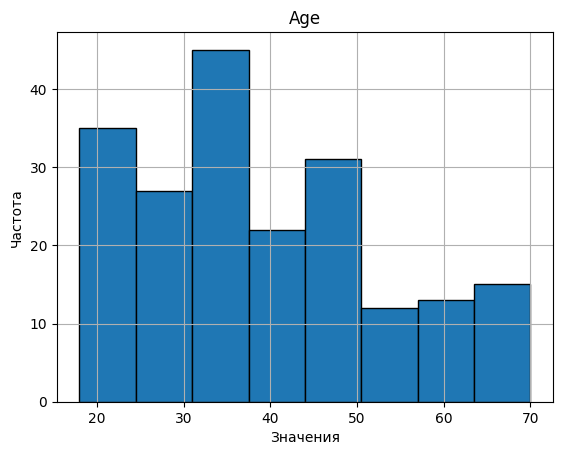

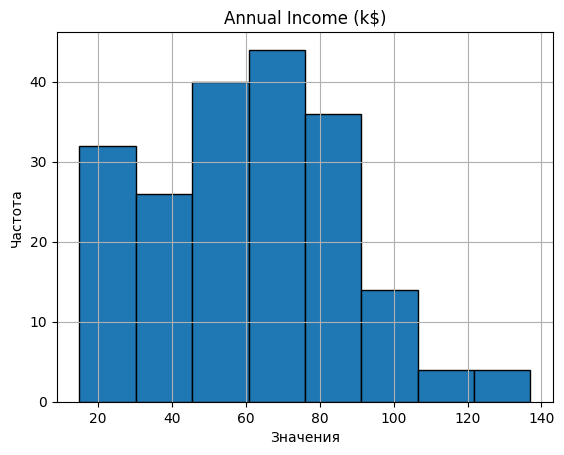

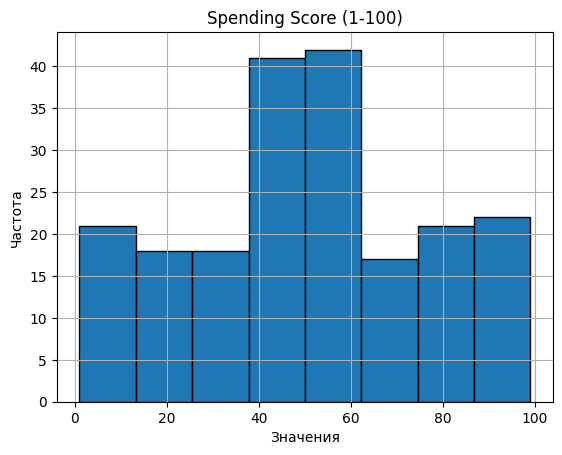

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA

df = pd.read_csv('Mall_Customers.csv')
df = df.drop(columns=['CustomerID'])
df = df.drop(columns=['Gender'])

columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

def build_histo(bins):
    for i in columns:
        df[i].hist(bins=int(bins), edgecolor='black')
        plt.title(i)
        plt.xlabel("Значения")
        plt.ylabel("Частота")
        plt.show()


print("Минимальные значения \n", df.min(), "\n")
print("Максимальные значения \n", df.max(), "\n")
print('Эксцесс\n', df.kurt(), "\n")
print('Медиана\n', df.median(), "\n")
print('Среднее\n', df.mean(), "\n")
print('Ст отклонение\n', df.std(), "\n")
print('Дисперсия\n', df.var(), "\n")
print('Ассиметрия\n', df.skew(), "\n")

k = 1 + 3.322*math.log10(len(df['Age']))
build_histo(k)

Датасет представляет собой статистику покупателей торгового центра. Выделяем группы покупателей по ежегодному доходу, возрасту и баллам лояльности. Пропущенных значений и выбросов нет, все признаки имеют информационную значимость. Возраст и доход имеют ассиметричное(положительно) нормальное распределение, баллы лояльности - симметричное

Исключены Gender и Id.

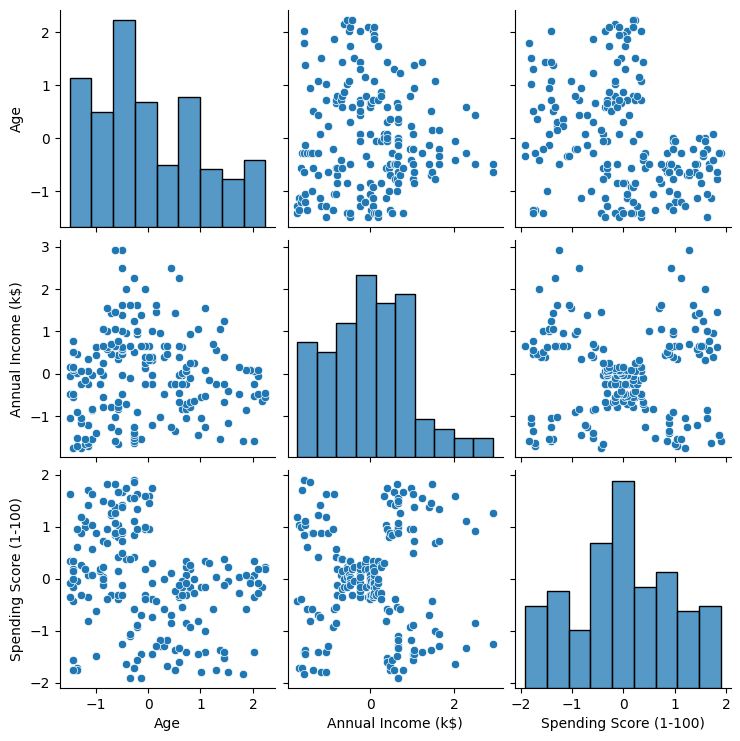

In [9]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
sns.pairplot(df_scaled)
plt.show()

Использован StandardScaler, так как признаки имеют разный масштаб (Age, Income, Spending Score). Стандартизация делает вклад признаков равным и позволяет корректно применять методы, основанные на евклидовом расстоянии.
Матрица диаграмм рассеивания показывает, что признак Age не формирует видимых кластеров. Наиболее выраженная структура — в пространстве Income–Spending Score. Кластеры частично пересекаются, имеют разную плотность и эллиптическую форму.
На основе форм и плотности данных, хорошим выбором является GMM(особенно эффективен, когда кластеры имеют эллиптическую форму или разную плотность данных). Agglomerative (Ward) хорошо подходит для плотной центральной области. KMeans применим, но может оказаться менее точным из-за несферичности кластеров.
Используем kmeans и GMM.

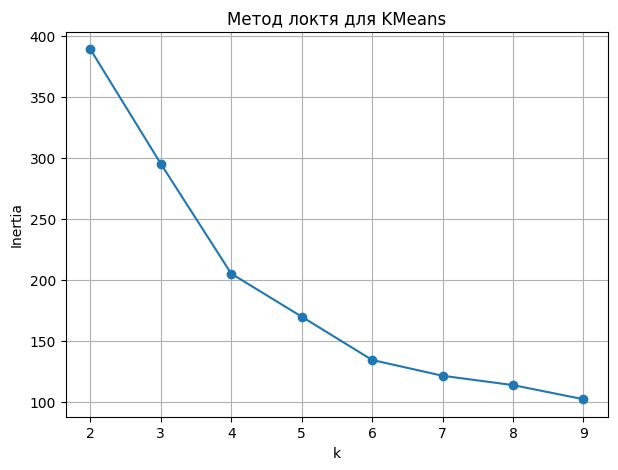

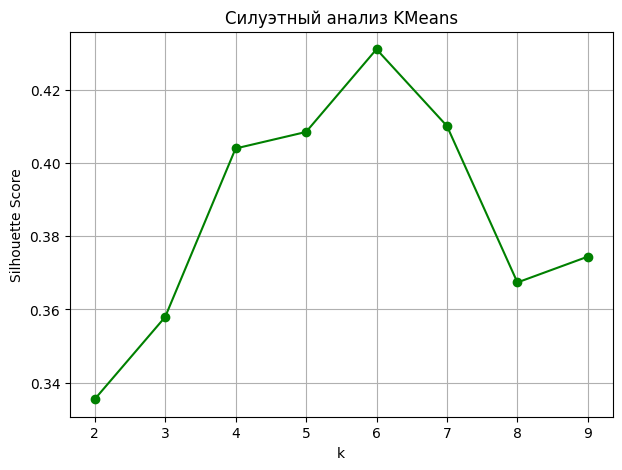

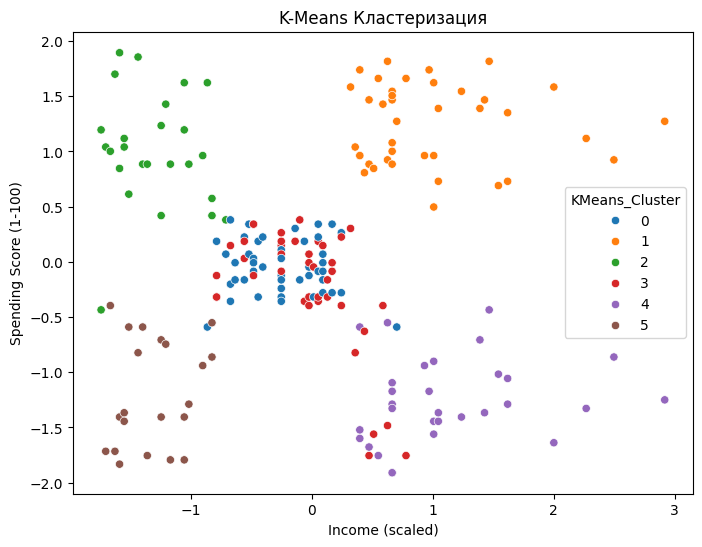

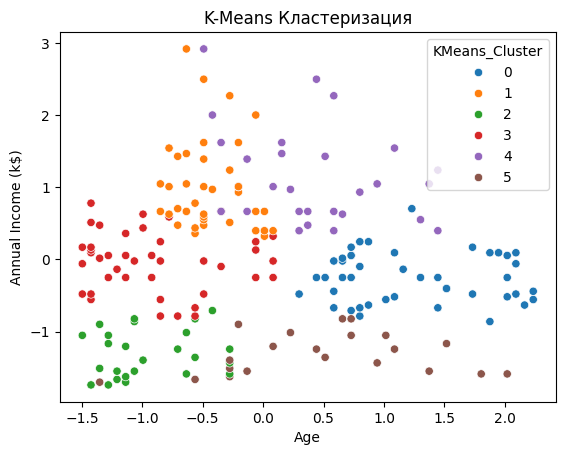

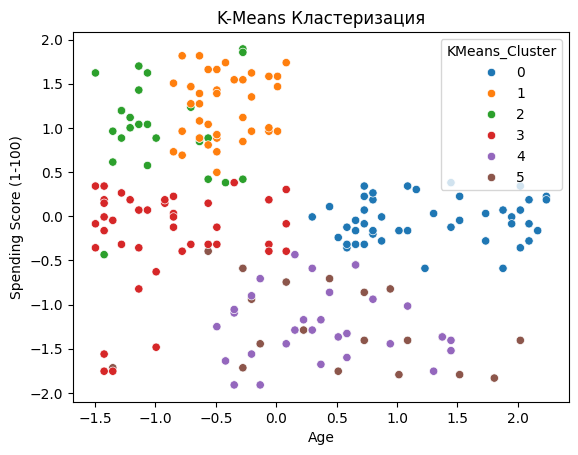

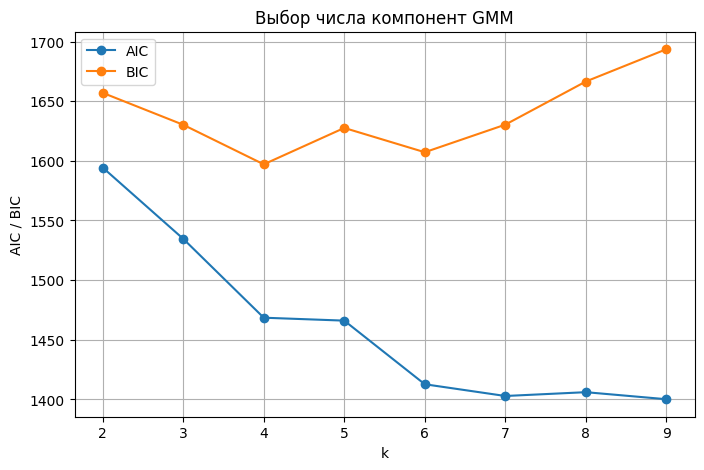

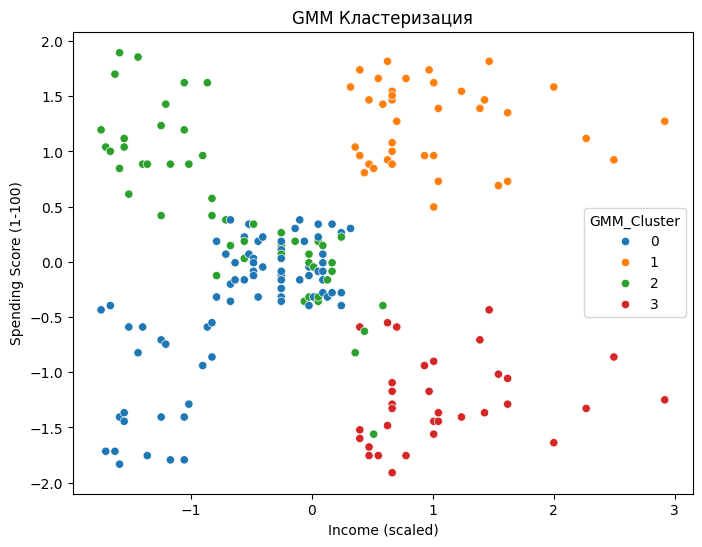

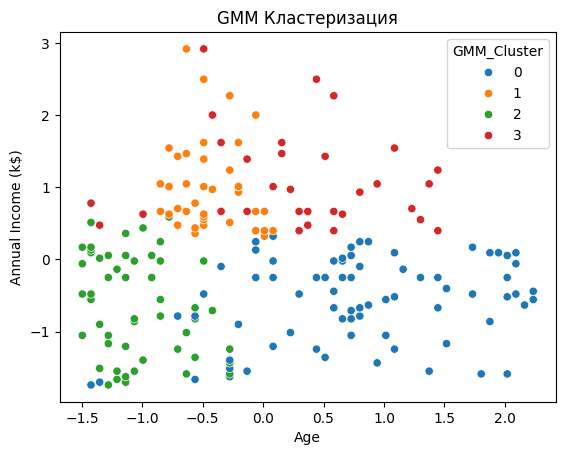

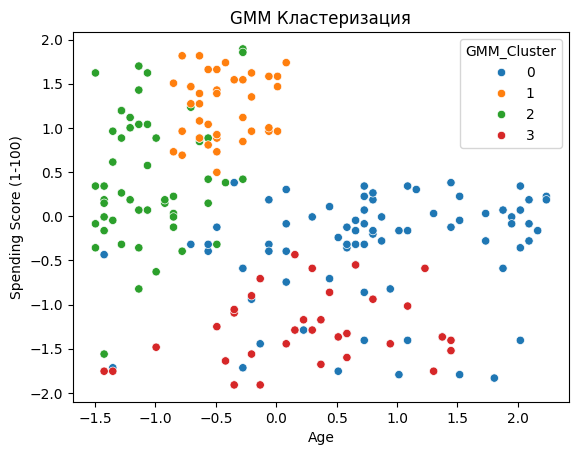

In [ ]:
inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Метод локтя для KMeans")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid()
plt.show()


silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df_scaled)
    silhouette_scores.append(silhouette_score(df_scaled, labels))

plt.figure(figsize=(7,5))
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.title("Силуэтный анализ KMeans")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

k_opt = 6

kmeans = KMeans(n_clusters=k_opt, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df_scaled)
kmeans_centers = kmeans.cluster_centers_
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_scaled['Annual Income (k$)'],
    y=df_scaled['Spending Score (1-100)'],
    hue=df['KMeans_Cluster'],
    palette="tab10"
)
plt.title("K-Means Кластеризация")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (1-100)")
plt.show()
sns.scatterplot(
    x=df_scaled['Age'],
    y=df_scaled['Annual Income (k$)'],
    hue=df['KMeans_Cluster'],
    palette="tab10"
)
plt.title("K-Means Кластеризация")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.show()
sns.scatterplot(
    x=df_scaled['Age'],
    y=df_scaled['Spending Score (1-100)'],
    hue=df['KMeans_Cluster'],
    palette="tab10"
)
plt.title("K-Means Кластеризация")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.show()


aic = []
bic = []
K_range = range(2, 10)

for k in K_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(df_scaled)
    aic.append(gmm.aic(df_scaled))
    bic.append(gmm.bic(df_scaled))

plt.figure(figsize=(8,5))
plt.plot(K_range, aic, label='AIC', marker='o')
plt.plot(K_range, bic, label='BIC', marker='o')
plt.xlabel("k")
plt.ylabel("AIC / BIC")
plt.title("Выбор числа компонент GMM")
plt.legend()
plt.grid()
plt.show()

gmm_opt = 4

gmm = GaussianMixture(n_components=gmm_opt, covariance_type='full', random_state=42)
df['GMM_Cluster'] = gmm.fit_predict(df_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_scaled['Annual Income (k$)'],
    y=df_scaled['Spending Score (1-100)'],
    hue=df['GMM_Cluster'],
    palette="tab10"
)
plt.title("GMM Кластеризация")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (1-100)")
plt.show()
sns.scatterplot(
    x=df_scaled['Age'],
    y=df_scaled['Annual Income (k$)'],
    hue=df['GMM_Cluster'],
    palette="tab10"
)
plt.title("GMM Кластеризация")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.show()
sns.scatterplot(
    x=df_scaled['Age'],
    y=df_scaled['Spending Score (1-100)'],
    hue=df['GMM_Cluster'],
    palette="tab10"
)
plt.title("GMM Кластеризация")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.show()

Реализовали 2 метода: K-means и EM-алгоритм. Подобрали оптимальное число кластеров для алгоритмов. Для K-means через метод локтя и анализ силуэта(для обоих способов оптимальное число 6), для EM через BIC(байесовский информационный критерий) и AIC(информационный критерий Акаике) - информационные критерии, позволяющие выбрать число компонент в вероятностных моделях, балансируя между качеством аппроксимации данных и сложностью модели. Анализ AIC/BIC показал, что лучшее число кластеров - 4

In [ ]:
sil_kmeans = silhouette_score(df_scaled, df['KMeans_Cluster'])
sil_gmm = silhouette_score(df_scaled, df['GMM_Cluster'])

print(f"Внутренние метрики\nМера компактности Inertia (KMeans): {kmeans.inertia_:.2f}")
print(f"Silhouette score (KMeans): {sil_kmeans:.3f}")
print(f"Silhouette score (GMM): {sil_gmm:.3f}")

X = df_scaled.values
labels_km = df['KMeans_Cluster'].values
centers_km = kmeans.cluster_centers_

intra_kmeans = {}
for i in range(k_opt):
    cluster_points = X[labels_km == i]
    distances = np.linalg.norm(cluster_points - centers_km[i], axis=1)
    intra_kmeans[i] = distances.mean()

print("\nСредние внутрикластерные расстояния (KMeans):")
for k, v in intra_kmeans.items():
    print(f"  Кластер {k}: {v:.3f}")


inter_kmeans = squareform(pdist(centers_km))
print("Матрица расстояний между центрами кластеров (KMeans):")
print(inter_kmeans)


centers_kmeans_orig = pd.DataFrame(
    scaler.inverse_transform(centers_km),
    columns=["Annual Income (k$)", "Spending Score (1-100)", "Age"]
)
print("Центры кластеров KMeans:")
print(centers_kmeans_orig)

labels_gmm = df['GMM_Cluster'].values
centers_gmm = gmm.means_

intra_gmm = {}
for i in range(gmm_opt):
    cluster_points = X[labels_gmm == i]
    distances = np.linalg.norm(cluster_points - centers_gmm[i], axis=1)
    intra_gmm[i] = distances.mean()

print("Средние внутрикластерные расстояния (GMM):")
for k, v in intra_gmm.items():
    print(f"  Компонента {k}: {v:.3f}")

inter_gmm = squareform(pdist(centers_gmm))

print("Матрица расстояний между центрами компонент (GMM):")
print(inter_gmm)

centers_gmm_orig = pd.DataFrame(
    scaler.inverse_transform(centers_gmm),
    columns=["Annual Income (k$)", "Spending Score (1-100)", "Age"]
)

print("Центры компонент GMM:")
print(centers_gmm_orig)


Внутренние метрики
Мера компактности Inertia (KMeans): 134.35
Silhouette score (KMeans): 0.431
Silhouette score (GMM): 0.373

Средние внутрикластерные расстояния (KMeans):
  Кластер 0: 0.695
  Кластер 1: 0.687
  Кластер 2: 0.642
  Кластер 3: 0.761
  Кластер 4: 0.859
  Кластер 5: 0.907
Матрица расстояний между центрами кластеров (KMeans):
[[0.         2.45830754 2.6674306  2.18423996 2.02939708 1.75231301]
 [2.45830754 0.         2.35994508 1.85276426 2.62453284 3.47433212]
 [2.6674306  2.35994508 0.         1.76239186 3.57463636 2.63158008]
 [2.18423996 1.85276426 1.76239186 0.         2.01970745 2.11786118]
 [2.02939708 2.62453284 3.57463636 2.01970745 0.         2.44012686]
 [1.75231301 3.47433212 2.63158008 2.11786118 2.44012686 0.        ]]
Центры кластеров KMeans:
   Annual Income (k$)  Spending Score (1-100)        Age
0           56.333333               54.266667  49.066667
1           32.692308               86.538462  82.128205
2           25.560000               26.480000  76

Значение меры компактности (inertia) для метода K-means при k = 6 составило 134.35. Данное значение свидетельствует о достаточной компактности кластеров и согласуется с результатами силуэтного анализа.
Silhouette Score - метрика для оценки качества кластеризации, которая позволяет измерить, насколько хорошо каждый объект помещён в свой кластер, а также насколько он далёк от других кластеров. Оценка лежит в диапазоне от -1 до 1. Силуэтный коэффициент для метода K-means составил 0.431 - умеренно хорошее качество кластеризации и приемлемая разделимость кластеров. Для модели Gaussian Mixture значение силуэтного коэффициента оказалось ниже (0.373), что объясняется вероятностной природой GMM и наличием перекрывающихся кластеров. В целом оба метода демонстрируют удовлетворительное качество кластеризации для данного набора данных.

Средние внутрикластерные расстояния для метода K-means находятся в диапазоне от 0.642 до 0.907. Наиболее компактным является кластер 2, что указывает на высокую однородность объектов внутри него. Кластеры 4 и 5 имеют наибольшие значения, что свидетельствует о более разнородном составе данных. В целом значения внутрикластерных расстояний находятся на сопоставимом уровне, что говорит о сбалансированной и устойчивой кластеризации.
Матрица расстояний между центрами кластеров - это евклидовы расстояния между центрами кластеров(в стандартизированном пространстве). Чем больше расстояние, тем сильнее различаются кластеры. Самыми близкими кластерами оказались 0 и 5, 2 и 3, 1 и 3. Самыми дальними - 2 и 4, 1 и 5, 1 и 4. Можно заметить, что самые далёкие кластеры имеют противоположные профили по возрасту и расходам.

GMM:
Для модели Gaussian Mixture средние внутрикластерные расстояния находятся в диапазоне от 0.687 до 1.092, что указывает на различную степень компактности компонент. Наиболее компактной является компонента 1, характеризующаяся однородным составом данных, компонента 0 является более размытым сегментом. Анализ расстояний между центрами компонент показал значения от 1.90 до 2.72, что свидетельствует о достаточной, но менее жёсткой разделимости по сравнению с K-means. Полученные компоненты обладают содержательной интерпретацией и отражают вероятностную структуру распределения клиентов, что подтверждает адекватность применения GMM для данной задачи.

In [ ]:
K_range = range(2, 11)

inertia_values = []
silhouette_values = []
davies_bouldin_values = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X, labels))
    davies_bouldin_values.append(davies_bouldin_score(X, labels))

results = pd.DataFrame({
    "k": list(K_range),
    "Inertia": inertia_values,
    "Silhouette score": silhouette_values,
    "Davies-Bouldin index": davies_bouldin_values
})

print(results)

    k     Inertia  Silhouette score  Davies-Bouldin index
0   2  389.386189          0.335472              1.260682
1   3  295.456245          0.357923              1.032689
2   4  205.225147          0.403958              0.930796
3   5  169.891498          0.408469              0.888969
4   6  134.352775          0.431065              0.834966
5   7  121.389350          0.410091              0.880755
6   8  113.727230          0.367366              0.952068
7   9  102.136238          0.374421              0.918146
8  10   92.550272          0.361870              0.988547


При увеличении числа кластеров значение inertia закономерно уменьшается, однако после k = 6 снижение становится менее выраженным. Силуэтный коэффициент достигает максимума при k = 6, после чего начинает снижаться, что указывает на ухудшение разделимости кластеров при дальнейшем увеличении k. Таким образом, значение k = 6 обеспечивает наилучший баланс между компактностью и разделимостью кластеров и является оптимальным для данного набора данных. Silhouette score при увеличении числа кластеров сначала возрастает, что говорит об улучшении разделимости кластеров, и достигает максимального значения при k = 6. При дальнейшем увеличении k силуэтный коэффициент снижается, что говорит об избыточном дроблении данных.
Метрика Davies-Bouldin index одновременно учитывает компактность кластеров и их разделимость. Если кластеры плотные внутри и далеко друг от друга, то индекс будет маленьким. Таким образом, опять же, лучшим выбором является 6 кластеров с показателем 0.83.

c:\Users\ggleb\Desktop\sis\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


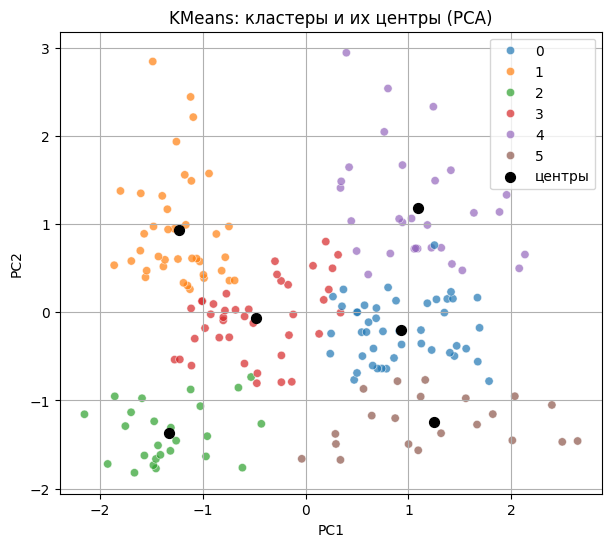

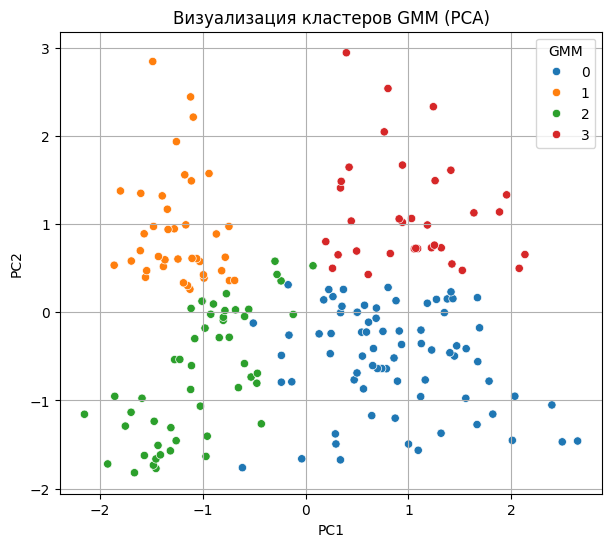

Доля объяснённой дисперсии PCA: [0.44266167 0.33308378]


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df_scaled)

pca_df = pd.DataFrame(
    X_pca, columns=["PC1", "PC2"]
)
pca_df["KMeans"] = df["KMeans_Cluster"]
pca_df["GMM"] = df["GMM_Cluster"]

centers_pca = pca.transform(kmeans_centers)
print()
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="KMeans",
    palette="tab10",
    alpha=0.7
)

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c="black",
    s=50,
    marker="o",
    label="центры"
)

plt.title("KMeans: кластеры и их центры")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2",
    hue="GMM", palette="tab10"
)
plt.title("Визуализация кластеров GMM")
plt.grid()
plt.show()


print("Доля объяснённой дисперсии PCA:", pca.explained_variance_ratio_)

Приведем содержательный анализ kmeans:
Кластер 0: покупают средне, доход средний, возраст большой
Кластер 1: хорошо покупают, высокий доход, возраст примерно средний
Кластер 2: хорошо покупают, доход низкий, возраст меньше среднего
Кластер 3: по покупательской способности и доходу схожи с клатером 0, однако возраст меньше среднего
Кластер 4: покупают плохо, высокий доход, возраст средний
Кластер 5: покупают плохо, доход низкий, возраст средний-большой

После применения медота главных компонент и выделения центров кластеров, становятся очевидными наблюдения:
видны 4 основных кластера, различающиеся по доходу и покупательной способности. Больше покупают молодые и часть людей среднего возраста(относительно датасета). Меньше покупают средневозрастные или выше.
Также есть еще 2 кластера с одинаковыми средними показателями и большим разбросом возраста.

В результате применения двух методов кластеризации становится понятным, что K-Means формирует более компактные и чётко интерпретируемые кластеры, хорошо соответствующие задаче дробления клиентов.
GMM позволяет выявить более гибкую структуру данных и учитывать перекрытие сегментов, однако полученные кластеры менее однозначны для практического применения.

Таким образом, для задачи маркетинговой сегментации клиентов метод K-Means является более предпочтительным, тогда как GMM может быть использован в качестве дополнительного инструмента анализа.